# Kiểm thử pipeline image_processor
Notebook này tái hiện từng bước chính của `sam3/backend/image_processor.py` để dễ dàng verify và kiểm thử.
Các section gồm: thiết lập môi trường, chạy SAM3 mask, matting, depth order, inpaint layer và inpaint background tổng thể.

In [2]:
import sys
from pathlib import Path
import io, base64, logging
from dataclasses import dataclass, field
from typing import List, Tuple
import numpy as np
import cv2
from PIL import Image
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'examples':
    ROOT = ROOT.parent

# Add backend to path so relative imports in image_processor work
backend_path = ROOT / 'backend'
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))
sys.path.insert(0, str(ROOT))

from backend.image_processor import _TH_ALPHA, _KERNEL_SCALE, _UNBLEND_ALPHA_CLIP, _PALETTE_PERCENTILE, _FG_REFINE_NUM_COLORS, _BG_REFINE_NUM_COLORS, _FG_REFINE_N_INNER_RATIO, _BG_REFINE_N_OUTER_RATIO
from backend.models import get_sam3_processor, get_lama_model, get_matting_model
from backend.helpers import (estimate_fg_color, estimate_fg_alpha, refine_background, expand_mask, find_flat_color_region_ccs, shrink_mask_ratio, expand_mask_ratio, divide_mask_to_connected_components)

print('ROOT =', ROOT)
print('Torch device available:', torch.cuda.is_available())

/home/intern/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/intern/anaconda3/envs/sam3/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


ROOT = /home/intern/sam3
Torch device available: True


In [3]:
def _image_to_base64(img: Image.Image, fmt: str = 'PNG') -> str:
    buf = io.BytesIO()
    img.save(buf, format=fmt)
    return base64.b64encode(buf.getvalue()).decode()

def _bbox_from_mask(mask: np.ndarray) -> Tuple[int, int, int, int] | None:
    rows = np.any(mask > 0, axis=1)
    cols = np.any(mask > 0, axis=0)
    if not rows.any():
        return None
    y0, y1 = np.where(rows)[0][[0, -1]]
    x0, x1 = np.where(cols)[0][[0, -1]]
    return int(x0), int(y0), int(x1 - x0 + 1), int(y1 - y0 + 1)

def _calc_kernel_size(image_np: np.ndarray) -> tuple[int, int]:
    h, w = image_np.shape[:2]
    return (round(h * _KERNEL_SCALE), round(w * _KERNEL_SCALE))

def _build_inpaint_mask(image_rgb: np.ndarray, hard_mask: np.ndarray, kernel_size: tuple[int, int]) -> np.ndarray:
    color_masks, _, ccs = find_flat_color_region_ccs(image_rgb, hard_mask, max_num_colors=_FG_REFINE_NUM_COLORS, percentile=_PALETTE_PERCENTILE)
    if len(ccs) == 0:
        return expand_mask(hard_mask, kernel_size)
    shrinked_ccs = [ccs[i] if len(color_masks[i]) == 0 else shrink_mask_ratio(ccs[i], _FG_REFINE_N_INNER_RATIO) for i in range(len(ccs))]
    combined = np.any(shrinked_ccs + sum(color_masks, []), axis=0)
    return expand_mask(combined, kernel_size)

def _refine_alpha_with_colors(image_rgb: np.ndarray, bg_np: np.ndarray, alpha: np.ndarray, hard_mask: np.ndarray, kernel_size: tuple[int, int]) -> tuple[np.ndarray, np.ndarray]:
    image_uint8 = image_rgb.astype(np.uint8)
    alpha = alpha.astype(np.float64)
    fg_rgb = estimate_fg_color(image_uint8, bg_np.astype(np.uint8), alpha, _UNBLEND_ALPHA_CLIP)
    color_masks, colors, ccs = find_flat_color_region_ccs(image_uint8, hard_mask, max_num_colors=_FG_REFINE_NUM_COLORS, percentile=_PALETTE_PERCENTILE)
    for colors_cc, color_masks_cc, cc in zip(colors, color_masks, ccs):
        _ref_alpha = np.zeros_like(alpha)
        _ref_color = np.zeros_like(fg_rgb)
        _nonzero = np.zeros_like(alpha)
        for color, cmask in zip(colors_cc, color_masks_cc):
            cmask_exp = expand_mask(cmask, kernel_size)
            ra = estimate_fg_alpha(cmask_exp, color, bg_np.astype(np.uint8), image_uint8)
            if ra is not None:
                _ref_alpha = np.maximum(_ref_alpha, ra)
                _ref_color[ra > 0] = color
                _nonzero += (ra > 0).astype(int)
        boundary = _nonzero > 1
        if _ref_alpha.sum() > 0:
            inner_cc = (~shrink_mask_ratio(cc, _FG_REFINE_N_INNER_RATIO)) & cc
            target = ((alpha == 0) | inner_cc) & (~boundary)
            alpha[target] = np.maximum(alpha[target], _ref_alpha[target])
            upd = target & (_ref_alpha > 0)
            fg_rgb[upd] = _ref_color[upd]
    return alpha, fg_rgb

def _estimate_depth_order(masks: List[np.ndarray]) -> List[int]:
    n = len(masks)
    overlap_scores = np.zeros(n)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            mi = masks[i].astype(bool)
            mj = masks[j].astype(bool)
            intersection = np.sum(mi & mj)
            if intersection == 0:
                continue
            ratio_i = intersection / np.sum(mi)
            ratio_j = intersection / np.sum(mj)
            if ratio_i > ratio_j:
                overlap_scores[i] += intersection
    return list(np.argsort(overlap_scores))

def _remove_occluder_with_seed(image_np: np.ndarray, target_mask: np.ndarray, occluder_mask: np.ndarray, lama, orig_size: tuple) -> np.ndarray:
    overlap = target_mask & occluder_mask
    if not np.any(overlap):
        return image_np.copy()
    visible_B = target_mask & (~occluder_mask)
    if np.sum(visible_B) == 0:
        return image_np.copy()
    B_colors = image_np[visible_B]
    B_mean_color = np.median(B_colors, axis=0).astype(np.uint8)
    seeded = image_np.copy()
    seeded[overlap] = B_mean_color
    kernel = np.ones((7, 7), np.uint8)
    overlap_u8 = overlap.astype(np.uint8) * 255
    eroded = cv2.erode(overlap_u8, kernel, iterations=2)
    inpaint_region = overlap_u8 & ~eroded
    if np.sum(inpaint_region) == 0:
        return seeded
    mask_pil = Image.fromarray(inpaint_region).convert('L')
    result = lama(Image.fromarray(seeded), mask_pil)
    if result.size != orig_size:
        result = result.resize(orig_size, Image.LANCZOS)
    return np.array(result.convert('RGB'), dtype=np.uint8)

def _build_source_image_for_object(original_np: np.ndarray, masks: List[np.ndarray], target_idx: int, depth_order: List[int], lama, orig_size: tuple) -> np.ndarray:
    target_pos = depth_order.index(target_idx)
    objects_above = depth_order[:target_pos]
    target_mask = masks[target_idx].astype(bool)
    occluders = [i for i in objects_above if np.any(masks[i].astype(bool) & target_mask)]
    if not occluders:
        return original_np.copy()
    current = original_np.copy()
    for occ_idx in occluders:
        current = _remove_occluder_with_seed(image_np=current, target_mask=target_mask, occluder_mask=masks[occ_idx].astype(bool), lama=lama, orig_size=orig_size)
    return current

Sử dụng ảnh: assets/images/composite.png


(-0.5, 6613.5, 4251.5, -0.5)

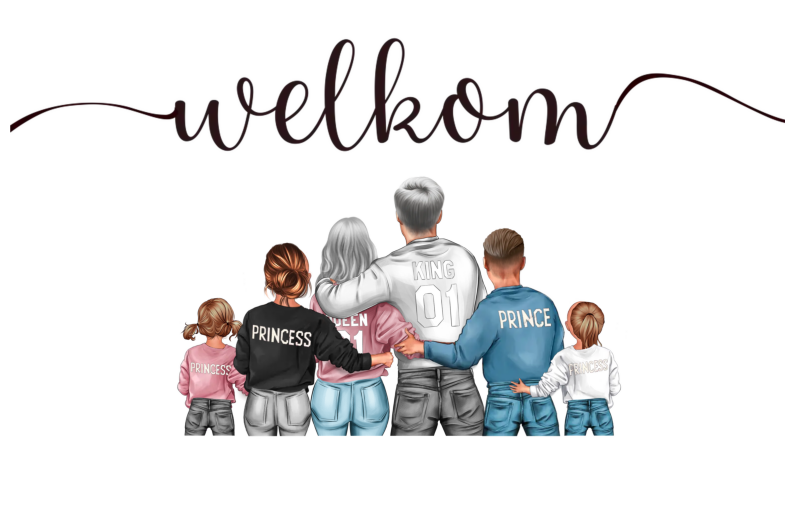

In [4]:
# Tải ảnh mẫu và hiển thị
sample_image_path = ROOT / 'assets/images/composite.png'
image = Image.open(sample_image_path).convert('RGB')
image_np = np.array(image, dtype=np.uint8)
print('Sử dụng ảnh:', sample_image_path.relative_to(ROOT))
plt.figure(figsize=(10, 8))
plt.imshow(image_np)
plt.axis('off')

found 6 object(s)
Keyword=person masks= 6
  person_0 score=0.910
  person_1 score=0.898
  person_2 score=0.914
  person_3 score=0.914
  person_4 score=0.918
  person_5 score=0.891
Tổng mask thu được: 6


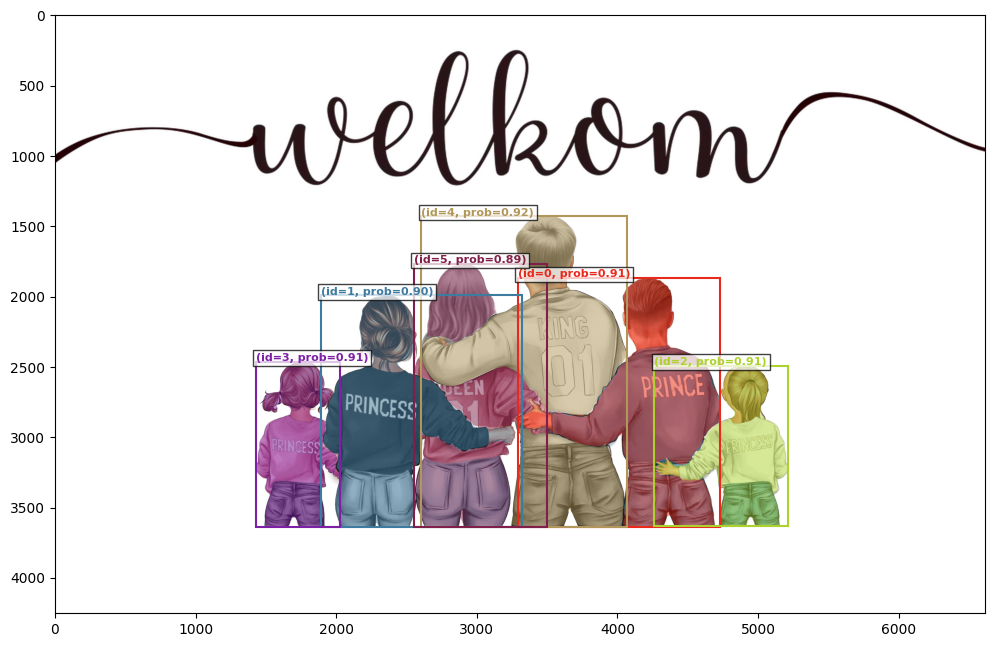

In [10]:
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results
import os
os.chdir(str(ROOT))  # Change to root so relative checkpoint path works

processor = get_sam3_processor()
keywords = ['person']  
raw_masks = []
labels = []
scores = []
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
mixed_dtype = (torch.bfloat16
                   if device_type == "cuda" and torch.cuda.is_bf16_supported()
                   else torch.float16)

# Move set_image inside autocast context to ensure proper dtype handling
with torch.no_grad(), torch.autocast(device_type, dtype=mixed_dtype):
    inference_state = processor.set_image(image)
    for keyword in keywords:
        k = keyword.strip()
        if not k:
            continue
        processor.reset_all_prompts(inference_state)
        inference_state = processor.set_text_prompt(state=inference_state, prompt=k)
        plot_results(image, inference_state)
        masks = inference_state.get('masks')
        scores_local = inference_state.get('scores')
        print(f'Keyword={k} masks=', len(masks) if masks is not None else 0)
        if masks is None or len(masks) == 0:
            continue
        for i, mt in enumerate(masks):
            mn = mt.squeeze(0)
            if hasattr(mn, 'cpu'):
                mn = mn.cpu().numpy()
            bin_mask = (mn > 0).astype(np.uint8) * 255
            raw_masks.append(bin_mask)
            label = f'{k}_{i}' if len(masks) > 1 else k
            labels.append(label)
            score = scores_local[i].item() if scores_local is not None else 1.0
            scores.append(score)
            print(f'  {label} score={score:.3f}')
print('Tổng mask thu được:', len(raw_masks))

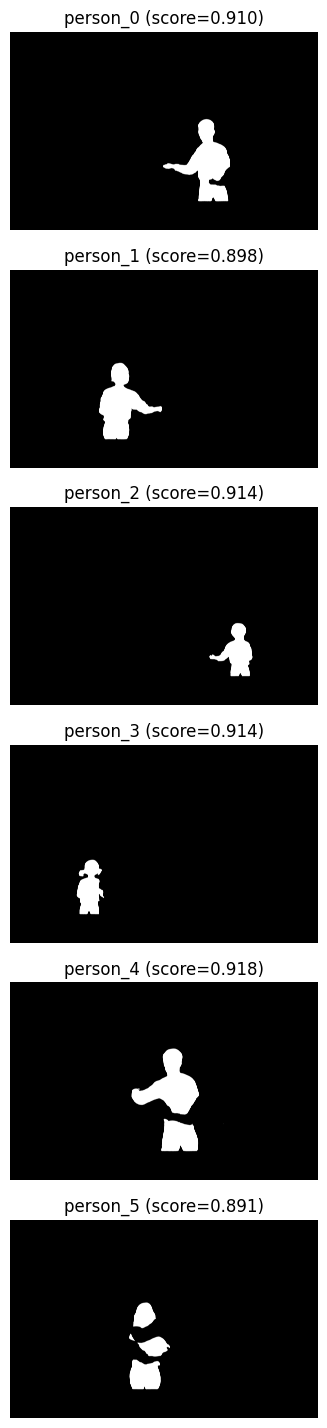

In [11]:
# Hiển thị mask SAM3
n = len(raw_masks)
if n == 0:
    raise RuntimeError('Không có mask nào để hiển thị.')
plt.figure(figsize=(12, 3 * n))
for i, mask in enumerate(raw_masks):
    plt.subplot(n, 1, i + 1)
    plt.imshow(mask, cmap='gray')
    plt.title(f'{labels[i]} (score={scores[i]:.3f})')
    plt.axis('off')

In [ ]:
# Chạy matting để sinh soft alpha cho mỗi mask
matting_model = get_matting_model()
soft_alphas = []
hard_masks = []
for idx, m_bin in enumerate(raw_masks):
    guided = image_np.copy()
    guided[m_bin == 0] = 0
    alpha_f = matting_model(Image.fromarray(guided))
    hard = alpha_f > _TH_ALPHA
    m_bin_tensor = torch.from_numpy(m_bin).to(alpha_f.device) > 0
    hard = hard & m_bin_tensor
    hard = hard.bool()
    alpha_f[~hard] = 0.0
    alpha_np = alpha_f.cpu().to(torch.float64).numpy()
    alpha_np = np.clip(alpha_np, 0.0, 1.0)
    soft_alphas.append(alpha_np)
    hard_masks.append(hard.cpu().numpy())
    print(f'Matting xong mask {labels[idx]} shape={alpha_np.shape}')

In [ ]:
# Hiển thị soft alpha và hard mask
plt.figure(figsize=(14, 4 * len(soft_alphas)))
for i, alpha in enumerate(soft_alphas):
    plt.subplot(len(soft_alphas), 2, 2 * i + 1)
    plt.imshow(alpha, cmap='viridis')
    plt.title(f'Soft alpha {labels[i]}')
    plt.axis('off')
    plt.subplot(len(soft_alphas), 2, 2 * i + 2)
    plt.imshow(hard_masks[i], cmap='gray')
    plt.title(f'Hard mask {labels[i]}')
    plt.axis('off')

In [ ]:
# Ước tính depth order
depth_order = _estimate_depth_order(raw_masks)
print('Depth order (top->bottom):', depth_order)
for rank, idx in enumerate(depth_order):
    print(f'  position {rank}: {labels[idx]}')

In [ ]:
# Inpaint background cho từng vật thể, loại bỏ occluder phía trên
lama = get_lama_model()
orig_size = image.size
object_sources = []
for idx in range(len(raw_masks)):
    source_np = _build_source_image_for_object(original_np=image_np, masks=raw_masks, target_idx=idx, depth_order=depth_order, lama=lama, orig_size=orig_size)
    object_sources.append(source_np)
    print(f'Đã tạo source image cho {labels[idx]}')

In [ ]:
# Hiển thị ảnh nguồn sau khi loại bỏ occluder
plt.figure(figsize=(12, 4 * len(object_sources)))
for i, src in enumerate(object_sources):
    plt.subplot(len(object_sources), 1, i + 1)
    plt.imshow(src)
    plt.title(f'Source image cho {labels[i]}')
    plt.axis('off')

In [ ]:
# Refine background và alpha cho từng layer
layer_rgba = []
kernel_size = _calc_kernel_size(image_np)
for idx, (source_np, alpha, label) in enumerate(zip(object_sources, soft_alphas, labels)):
    hard_mask = alpha > _TH_ALPHA
    inpaint_mask_fg = _build_inpaint_mask(source_np, hard_mask, kernel_size)
    mask_pil = Image.fromarray(inpaint_mask_fg).convert('L')
    source_img = Image.fromarray(source_np)
    bg_pil = lama(source_img, mask_pil)
    if bg_pil.size != orig_size:
        bg_pil = bg_pil.resize(orig_size, Image.LANCZOS)
    bg_np = np.array(bg_pil.convert('RGB'), dtype=np.uint8)
    bg_np = refine_background(bg_np, inpaint_mask_fg.astype(bool), n_outer_ratio=_BG_REFINE_N_OUTER_RATIO, max_num_colors=_BG_REFINE_NUM_COLORS)
    alpha_refined, fg_rgb = _refine_alpha_with_colors(source_np, bg_np, alpha.copy(), hard_mask, kernel_size)
    bbox = _bbox_from_mask((alpha_refined > _TH_ALPHA).astype(np.uint8) * 255)
    if bbox is None:
        continue
    x, y, w, h = bbox
    fg_crop = fg_rgb[y:y+h, x:x+w]
    alpha_crop = (alpha_refined[y:y+h, x:x+w] * 255).astype(np.uint8)
    rgba_arr = np.dstack([fg_crop, alpha_crop])
    layer_rgba.append((label, Image.fromarray(rgba_arr, mode='RGBA'), bg_np, inpaint_mask_fg))
    print(f'Layer {label} tạo xong, bbox={bbox}')

In [ ]:
# Hiển thị layer RGBA và background refined cho từng object
plt.figure(figsize=(14, 5 * len(layer_rgba)))
for i, (label, rgba_img, bg_np, mask) in enumerate(layer_rgba):
    plt.subplot(len(layer_rgba), 3, 3 * i + 1)
    plt.imshow(rgba_img)
    plt.title(f'RGBA {label}')
    plt.axis('off')
    plt.subplot(len(layer_rgba), 3, 3 * i + 2)
    plt.imshow(bg_np)
    plt.title(f'Background refined {label}')
    plt.axis('off')
    plt.subplot(len(layer_rgba), 3, 3 * i + 3)
    plt.imshow(mask, cmap='gray')
    plt.title(f'Inpaint mask {label}')
    plt.axis('off')

In [ ]:
# Inpaint background tổng thể với union mask
union_mask = np.zeros_like(raw_masks[0])
for m in raw_masks:
    union_mask = np.maximum(union_mask, m)
union_mask = expand_mask(union_mask > 0, kernel_size)
final_bg = lama(image, Image.fromarray(union_mask).convert('L'))
if final_bg.size != orig_size:
    final_bg = final_bg.resize(orig_size, Image.LANCZOS)
final_bg_np = np.array(final_bg.convert('RGB'), dtype=np.uint8)
final_bg_np = refine_background(final_bg_np, union_mask.astype(bool), n_outer_ratio=_BG_REFINE_N_OUTER_RATIO, max_num_colors=_BG_REFINE_NUM_COLORS)
plt.figure(figsize=(10, 8))
plt.imshow(final_bg_np)
plt.title('Background tổng thể đã inpaint')
plt.axis('off')

In [ ]:
# Hiển thị tất cả các layer và background cuối cùng
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(final_bg_np)
plt.title('Background cuối cùng')
plt.axis('off')
plt.subplot(1, 2, 2)
combined = Image.new('RGBA', image.size, (0, 0, 0, 0))
for label, rgba_img, _, _ in layer_rgba:
    combined.alpha_composite(rgba_img)
plt.imshow(combined)
plt.title('Tổng hợp layers RGBA')
plt.axis('off')